Klein Gordon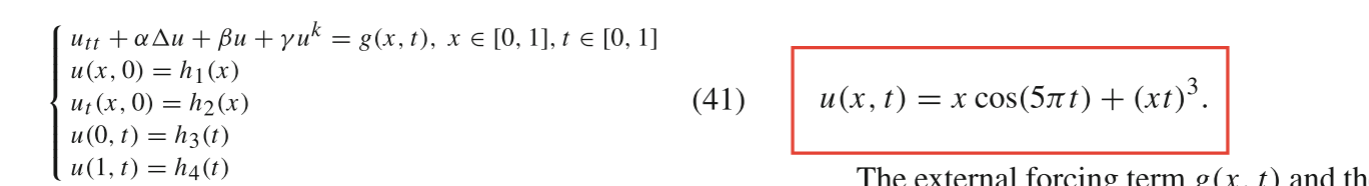

In [115]:
import torch
import torch.nn as nn
from torch.autograd import Variable
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import time
from collections import OrderedDict

a = -1  # Klein-Gordon方程系数
b = 0   # Klein-Gordon方程系数
c = 1   # Klein-Gordon方程系数
k = 3   # 非线性项指数
num_epochs = 10000
nu = 0.1

In [116]:
def analytical_solution(t, x):
    # Klein-Gordon方程解析解 u(x,t) = x * cos(5 * π * t) + (x * t)^3
    u = x * torch.cos(5 * torch.pi * t) + torch.pow(x * t, 3)
    return u.reshape(-1, 1)

def U_tt(x, t):
    return -25 * torch.pi**2 * x * torch.cos(5 * torch.pi * t) + 6 * t * x**3

def U_xx(x, t):
    return 6 * x * t**3

def PDE_source(x, t):
    # Klein-Gordon方程右侧源项
    return U_tt(x, t) + a * U_xx(x, t) + b * analytical_solution(t, x) + c * torch.pow(analytical_solution(t, x), k)

In [117]:
class PINN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(PINN, self).__init__()
        self.linear1 = nn.Linear(input_size, hidden_size)
        self.linear2 = nn.Linear(hidden_size, hidden_size)
        self.linear3 = nn.Linear(hidden_size, hidden_size)
        self.linear4 = nn.Linear(hidden_size, hidden_size)
        self.output = nn.Linear(hidden_size, 1)  
        self.tanh = nn.Tanh()
        self.iter = 0

    def forward(self, x, t=None):
        if t is not None:
            # 分开的x和t作为输入
            inputs = torch.cat([t, x], dim=1)  # 注意顺序是[t,x]
        else:
            # 已经组合的输入
            inputs = x
            
        out = self.linear1(inputs)
        out = self.tanh(out)
        out = self.linear2(out)
        out = self.tanh(out)
        out = self.linear3(out)
        out = self.tanh(out)
        out = self.linear4(out)
        out = self.tanh(out)
        out = self.output(out)
        return out

In [118]:
# 从sampling_PDE.py引入的DNN类
class DNN(torch.nn.Module):
    def __init__(self, layers):
        super(DNN, self).__init__()

        # parameters
        self.depth = len(layers) - 1

        # set up layer order dict
        self.activation = torch.nn.Tanh

        layer_list = list()
        for i in range(self.depth - 1):
            layer_list.append(
                ('layer_%d' % i, torch.nn.Linear(layers[i], layers[i + 1]))
            )
            layer_list.append(('activation_%d' % i, self.activation()))

        layer_list.append(
            ('layer_%d' % (self.depth - 1), torch.nn.Linear(layers[-2], layers[-1]))
        )
        layerDict = OrderedDict(layer_list)

        # deploy layers
        self.layers = torch.nn.Sequential(layerDict)

    def forward(self, x):
        out = self.layers(x)
        return out

# MMPDE采样类
class sampling_MMPDE():
    def __init__(self, X_f, u_fun, layers, lb, ub, nu, AdamIter, LBFGSIter):
        # 边界条件
        self.lb = torch.tensor(lb).float()
        self.ub = torch.tensor(ub).float()

        # 数据
        self.t_f = torch.tensor(X_f[:, 0:1], requires_grad=True).float()
        self.x_f = torch.tensor(X_f[:, 1:2], requires_grad=True).float()
        self.fun = u_fun

        self.layers = layers
        self.nu = nu

        # 深度神经网络
        self.dnn = DNN(layers)

        # 优化器设置
        self.optimizer_Adam = torch.optim.Adam(self.dnn.parameters(),
                                              lr=1e-3,
                                              betas=(0.9, 0.999),
                                              eps=1e-8)
        
        self.AdamIter = AdamIter

        self.optimizer_LBFGS = torch.optim.LBFGS(
            self.dnn.parameters(),
            lr=0.5,
            max_iter=LBFGSIter,
        )

        self.optimizer = None
        self.loss = None
        self.iter = 0
        self.start_time = None

    def detach(self, data):
        return data.detach().cpu().numpy()

    def monitor(self, u, t, x):

        # 计算u对t的一阶导数
        u_t = torch.autograd.grad(
            u, t,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True
        )[0]
        
        # 计算u对t的二阶导数(utt)
        u_tt = torch.autograd.grad(
            u_t, t,
            grad_outputs=torch.ones_like(u_t),
            retain_graph=True,
            create_graph=True
        )[0]
        
        # 计算u对x的一阶导数
        u_x = torch.autograd.grad(
            u, x,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True
        )[0]
        
        # 计算u对x的二阶导数(uxx)
        u_xx = torch.autograd.grad(
            u_x, x,
            grad_outputs=torch.ones_like(u_x),
            retain_graph=True,
            create_graph=True
        )[0]
        
        w = (1 + (0.5 * u_xx ** 2)  + (0.5 * u_tt ** 2)) ** (1 / 2)
        
        return w

    def net_sample(self, t, x):
        # 生成新的采样点
        xNew = self.dnn(torch.cat([t, x], dim=1))
        g0 = x - self.lb[1]
        g1 = x - self.ub[1]
        xNew = g0*g1*xNew + x
        return xNew

    def net_f(self, t, x):
        # 计算MMPDE方程的残差
        xNew = self.net_sample(t, x)

        xNew_t = torch.autograd.grad(
            xNew, t,
            grad_outputs=torch.ones_like(xNew),
            retain_graph=True,
            create_graph=True
        )[0]

        xNew_x = torch.autograd.grad(
            xNew, x,
            grad_outputs=torch.ones_like(xNew),
            retain_graph=True,
            create_graph=True
        )[0]
        
        xNew_xx = torch.autograd.grad(
            xNew_x, x,
            grad_outputs=torch.ones_like(xNew_x),
            retain_graph=True,
            create_graph=True
        )[0]

        # 计算解及其导数
        u = self.fun(torch.cat([t, x], dim=1))
        
        # 直接调用修改后的monitor函数，传入u,t,x
        G = self.monitor(u, t, x)

        G_t = torch.autograd.grad(
            G, t,
            grad_outputs=torch.ones_like(G),
            retain_graph=True,
            create_graph=True
        )[0]

        G_x = torch.autograd.grad(
            G, x,
            grad_outputs=torch.ones_like(G),
            retain_graph=True,
            create_graph=True
        )[0]

        # 不再需要G_tx的计算，因为我们已经在monitor函数中处理了二阶导数

        E = G_x * xNew_x + G * xNew_xx
        f = xNew_t*self.nu*(G**2)*(xNew_x**2) + E

        return f

    def loss_func(self):
        # 计算损失函数
        f_pred = self.net_f(self.t_f, self.x_f)
        loss_f = torch.mean(f_pred ** 2)
        
        return loss_f

    def optimize_one_epoch(self):
        if self.start_time is None:
            self.start_time = time.time()

        # 损失函数初始化
        self.optimizer.zero_grad()
        self.loss = self.loss_func()
        self.loss.backward()
        self.iter = self.iter + 1

        if self.iter % 100 == 0:
            loss = self.detach(self.loss)
            print(f"{self.optimizer_name} Iter {self.iter}, Loss: {loss:.6f}")
            elapsed = time.time() - self.start_time
            print(f'Time: {elapsed:.4f}s')
            self.start_time = time.time()

        return self.loss

    def train_Adam(self, optimizer, nIter):
        self.optimizer = optimizer
        self.optimizer_name = 'MMPDE_Adam'
        
        for it in range(nIter):
            self.optimize_one_epoch()
            self.optimizer.step()

    def train_LBFGS(self, optimizer):
        self.optimizer = optimizer
        self.optimizer_name = 'MMPDE_LBFGS'

        def closure():
            loss = self.optimize_one_epoch()
            return loss

        self.optimizer.step(closure)

    def train(self):
        # 训练过程
        print("开始MMPDE训练...")
        self.train_Adam(self.optimizer_Adam, self.AdamIter)
        print("MMPDE_Adam 完成!")
        self.train_LBFGS(self.optimizer_LBFGS)
        print('MMPDE_LBGFS 完成!')

        # 返回新的采样点
        new_x = self.net_sample(self.t_f, self.x_f)
        new_sample = torch.cat([self.t_f, new_x], dim=1)
        return new_sample

In [119]:
def create_simulation_function(model=None):
    # 如果没有提供模型，则使用Klein-Gordon方程的解析解
    def simulation_function(xt):
        t, x = xt[:, 0:1], xt[:, 1:2]
        # Klein-Gordon方程解析解: u(x,t) = x * cos(5 * π * t) + (x * t)^3
        return x * torch.cos(5 * torch.pi * t) + torch.pow(x * t, 3)
        
    return simulation_function

开始MMPDE训练...
MMPDE_Adam Iter 100, Loss: 6177.156250
Time: 0.7099s
MMPDE_Adam Iter 200, Loss: 5453.189453
Time: 0.7051s
MMPDE_Adam Iter 300, Loss: 4481.760742
Time: 0.7103s
MMPDE_Adam Iter 400, Loss: 4265.717773
Time: 0.7019s
MMPDE_Adam Iter 500, Loss: 4099.493652
Time: 0.7108s
MMPDE_Adam Iter 600, Loss: 3831.682129
Time: 0.6834s
MMPDE_Adam Iter 700, Loss: 3386.147949
Time: 0.7040s
MMPDE_Adam Iter 800, Loss: 2790.968994
Time: 0.7144s
MMPDE_Adam Iter 900, Loss: 1722.286133
Time: 0.6544s
MMPDE_Adam Iter 1000, Loss: 472.635864
Time: 0.6876s
MMPDE_Adam Iter 1100, Loss: 206.652466
Time: 0.6727s
MMPDE_Adam Iter 1200, Loss: 185.665985
Time: 0.6783s
MMPDE_Adam Iter 1300, Loss: 170.152756
Time: 0.6953s
MMPDE_Adam Iter 1400, Loss: 161.007858
Time: 0.7013s
MMPDE_Adam Iter 1500, Loss: 157.638000
Time: 0.7044s
MMPDE_Adam Iter 1600, Loss: 149.842422
Time: 0.6831s
MMPDE_Adam Iter 1700, Loss: 144.007370
Time: 0.7407s
MMPDE_Adam Iter 1800, Loss: 138.230911
Time: 0.7115s
MMPDE_Adam Iter 1900, Loss: 136.3

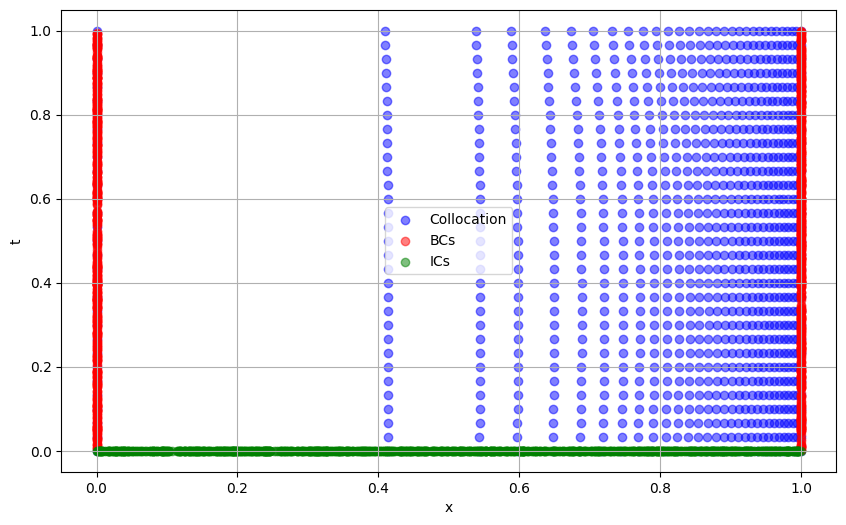

In [120]:
# 修改仿真域范围
lb = [0.0, 0.0]  # [t_min, x_min]
ub = [1.0, 1.0]  # [t_max, x_max] - 将t_max从1.0改为5.0

# 生成均匀分布的采样点
num_samples_per_dim = int(np.sqrt(1000))  # 每个维度上采样约100个点
x_uniform = torch.linspace(0, 1, num_samples_per_dim)  # x范围保持[0,1]
t_uniform = torch.linspace(0, 1, num_samples_per_dim)  # t范围改为[0,5]

# 创建均匀网格
X_grid, T_grid = torch.meshgrid(x_uniform, t_uniform, indexing='ij')
x_init = X_grid.reshape(-1, 1)
t_init = T_grid.reshape(-1, 1)

# 合并为输入样本
X_f_init = torch.cat([t_init, x_init], dim=1).numpy()

# 创建模拟函数
sim_func = create_simulation_function()

# 定义MMPDE参数
mmpde_layers = [2, 20, 20, 20, 1]  # 输入(t,x)，输出新的x坐标
adam_iter = 5000
lbfgs_iter = 1000

# 创建MMPDE采样器并训练
mmpde_sampler = sampling_MMPDE(
    X_f=X_f_init,
    u_fun=sim_func,
    layers=mmpde_layers,
    lb=lb,
    ub=ub,
    nu=nu,
    AdamIter=adam_iter,
    LBFGSIter=lbfgs_iter
)

# 训练MMPDE并获取优化后的采样点
new_samples = mmpde_sampler.train()

# 提取优化后的采样点
t_colloc = new_samples[:, 0:1].clone().detach().requires_grad_(True)
x_colloc = new_samples[:, 1:2].clone().detach().requires_grad_(True)
x_colloc_combined = torch.cat([t_colloc, x_colloc], dim=1)


# 生成边界条件点
N_bc = 1000
t_bc = torch.rand(N_bc, 1) * (ub[0] - lb[0]) + lb[0]  # t ∈ [0, 5]
x_bc_left = torch.zeros(N_bc//2, 1)  # x = 0
x_bc_right = torch.ones(N_bc//2, 1)   # x = 1
x_bc = torch.cat([x_bc_left, x_bc_right], dim=0)
t_bc_split = torch.split(t_bc, N_bc//2)
x_bc_left_combined = torch.cat([t_bc_split[0], x_bc_left], dim=1)
x_bc_right_combined = torch.cat([t_bc_split[1], x_bc_right], dim=1)
x_bc_combined = torch.cat([x_bc_left_combined, x_bc_right_combined], dim=0)
x_bc_combined.requires_grad_(True)

# 初始条件点(t=0)
N_ic = 1000
x_ic = torch.rand(N_ic, 1)  # x ∈ [-1, 1]
t_ic = torch.zeros(N_ic, 1)
x_ic_combined = torch.cat([t_ic, x_ic], dim=1)
x_ic_combined.requires_grad_(True)

# 可视化采样点
plt.figure(figsize=(10, 6))
plt.scatter(x_colloc.detach().numpy(), t_colloc.detach().numpy(), color='blue', alpha=0.5, label='Collocation')
plt.scatter(x_bc.detach().numpy(), t_bc.detach().numpy(), color='red', alpha=0.5, label='BCs')
plt.scatter(x_ic.detach().numpy(), t_ic.detach().numpy(), color='green', alpha=0.5, label='ICs')
plt.xlabel('x')
plt.ylabel('t')
plt.legend()
plt.grid(True)
plt.show()

In [121]:
def x_f_loss_fun(inputs, model):
    """
    计算Klein-Gordon方程PDE残差: u_tt + a*u_xx + b*u + c*u^k = f(x,t)
    """
    if not inputs.requires_grad:
        inputs = Variable(inputs, requires_grad=True)
    
    # 获取模型预测的u
    u = model(inputs)
    
    # 提取坐标
    t = inputs[:, 0:1]
    x = inputs[:, 1:2]
    
    # 计算u关于输入的梯度
    u_grad = torch.autograd.grad(u, inputs, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_t = u_grad[:, 0:1]  # 第一列是关于t的导数
    u_x = u_grad[:, 1:2]  # 第二列是关于x的导数
    
    # 计算u_tt - 对u_t再求一次关于t的导数
    u_tt = torch.autograd.grad(u_t, inputs, grad_outputs=torch.ones_like(u_t), create_graph=True)[0][:, 0:1]
    
    # 计算u_xx - 对u_x再求一次关于x的导数
    u_xx = torch.autograd.grad(u_x, inputs, grad_outputs=torch.ones_like(u_x), create_graph=True)[0][:, 1:2]
    
    # 计算源项
    source = PDE_source(x, t)
    
    # 计算残差: u_tt + a*u_xx + b*u + c*u^k - f(x,t)
    f = u_tt + a * u_xx + b * u + c * torch.pow(u, k) - source
    
    return f

In [122]:
def boundary_loss(model, x_bc):
    """边界条件损失：u在边界上为精确解"""
    outputs = model(x_bc)
    
    # 提取t和x坐标
    t = x_bc[:, 0:1]
    x = x_bc[:, 1:2]
    
    # 计算边界精确解
    u_bc_target = analytical_solution(t, x)
    
    return torch.mean((outputs - u_bc_target)**2)

def initial_condition_loss(model, x_ic):
    """
    初始条件损失：
    1. u(x,0) = x (位移)
    2. u_t(x,0) = 0 (初始速度)
    """
    inputs = x_ic.clone().requires_grad_(True)
    outputs = model(inputs)
    
    # 提取x坐标
    x = inputs[:, 1:2]
    
    # 计算初始位移误差 (u(x,0) = x)
    u_ic_target = x  # 在t=0时，u(x,0) = x
    disp_loss = torch.mean((outputs - u_ic_target)**2)
    
    # 计算初始速度误差 (u_t(x,0) = 0)
    u_t = torch.autograd.grad(
        outputs, inputs, 
        grad_outputs=torch.ones_like(outputs),
        create_graph=True
    )[0][:, 0:1]  # 对时间的导数
    
    vel_loss = torch.mean(u_t**2)  # 初始速度应为0
    
    return disp_loss + vel_loss

In [123]:
# 创建模型
model = PINN(2, 40)  # 输入维度是2 (t和x)，隐藏层维度40
model.iter = 0  # 添加迭代计数器

# 优化器参数
adam_iter = 5000  # Adam迭代次数
lbfgs_iter = 20000  # LBFGS迭代次数
adam_lr = 0.001  # Adam学习率
lbfgs_lr = 0.5  # LBFGS学习率

# 定义Adam优化器
optimizer_adam = torch.optim.Adam(model.parameters(), lr=adam_lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer_adam, step_size=1000, gamma=0.5)

# 第一阶段：Adam优化
print("开始第一阶段: Adam优化...")
for epoch in range(adam_iter):
    optimizer_adam.zero_grad()
    
    # 计算PDE残差
    f = x_f_loss_fun(x_colloc_combined, model)
    loss_pde = torch.mean(f**2)
    
    # 计算边界条件损失
    loss_bc = boundary_loss(model, x_bc_combined)
    
    # 计算初始条件损失
    loss_ic = initial_condition_loss(model, x_ic_combined)
    
    # 总损失
    total_loss = loss_pde + 10.0 * loss_bc + 10.0 * loss_ic
    
    total_loss.backward()
    
    # 添加梯度裁剪
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    
    optimizer_adam.step()
    scheduler.step()
    model.iter += 1
    
    if epoch % 100 == 0:
        print(f"Epoch: {epoch}/{adam_iter}, "
              f"Loss: {total_loss.item():.6e}, "
              f"PDE: {loss_pde.item():.6e}, "
              f"BC: {loss_bc.item():.6e}, "
              f"IC: {loss_ic.item():.6e}")

# 定义LBFGS优化器
optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(), 
    lr=lbfgs_lr, 
    max_iter=20,
    max_eval=25,
    tolerance_grad=1e-9,
    tolerance_change=1e-12,
    history_size=50,
    line_search_fn="strong_wolfe"
)

# 第二阶段：LBFGS优化
print("开始第二阶段: LBFGS优化...")

# 为LBFGS定义闭包函数
def closure():
    optimizer_lbfgs.zero_grad()
    
    # 计算PDE残差
    f = x_f_loss_fun(x_colloc_combined, model)
    loss_pde = torch.mean(f**2)
    
    # 计算边界条件损失
    loss_bc = boundary_loss(model, x_bc_combined)
    
    # 计算初始条件损失
    loss_ic = initial_condition_loss(model, x_ic_combined)
    
    # 总损失
    total_loss = loss_pde + 10.0 * loss_bc + 10.0 * loss_ic
    
    total_loss.backward()
    
    model.iter += 1
    if model.iter % 100 == 0:
        print(f"LBFGS Iter: {model.iter}, "
              f"Loss: {total_loss.item():.6e}, "
              f"PDE: {loss_pde.item():.6e}, "
              f"BC: {loss_bc.item():.6e}, "
              f"IC: {loss_ic.item():.6e}")
    
    return total_loss

# 运行LBFGS优化
for i in range(lbfgs_iter // 20):  # 由于max_iter设为20，我们在外层循环控制总迭代次数
    optimizer_lbfgs.step(closure)
    current_loss = closure()
    print(f"LBFGS外循环 {i+1}/{lbfgs_iter//20}, 当前损失: {current_loss.item():.6e}")

print("优化完成!")

开始第一阶段: Adam优化...
Epoch: 0/5000, Loss: 2.195141e+04, PDE: 2.194257e+04, BC: 3.660423e-01, IC: 5.184739e-01
Epoch: 100/5000, Loss: 1.657768e+04, PDE: 1.650895e+04, BC: 9.534578e-01, IC: 5.919870e+00
Epoch: 200/5000, Loss: 1.117915e+04, PDE: 1.095000e+04, BC: 6.103658e+00, IC: 1.681131e+01
Epoch: 300/5000, Loss: 8.550875e+03, PDE: 8.433859e+03, BC: 4.656269e+00, IC: 7.045351e+00
Epoch: 400/5000, Loss: 7.384610e+03, PDE: 7.202354e+03, BC: 5.520164e+00, IC: 1.270540e+01
Epoch: 500/5000, Loss: 7.196414e+03, PDE: 7.032206e+03, BC: 4.283013e+00, IC: 1.213785e+01
Epoch: 600/5000, Loss: 7.042024e+03, PDE: 6.865332e+03, BC: 4.057062e+00, IC: 1.361217e+01
Epoch: 700/5000, Loss: 5.134712e+03, PDE: 4.963911e+03, BC: 5.281872e+00, IC: 1.179828e+01
Epoch: 800/5000, Loss: 4.001358e+03, PDE: 3.898386e+03, BC: 3.615454e+00, IC: 6.681744e+00
Epoch: 900/5000, Loss: 3.335776e+03, PDE: 3.266681e+03, BC: 4.469190e+00, IC: 2.440356e+00
Epoch: 1000/5000, Loss: 3.158320e+03, PDE: 3.075825e+03, BC: 5.214118e+00,

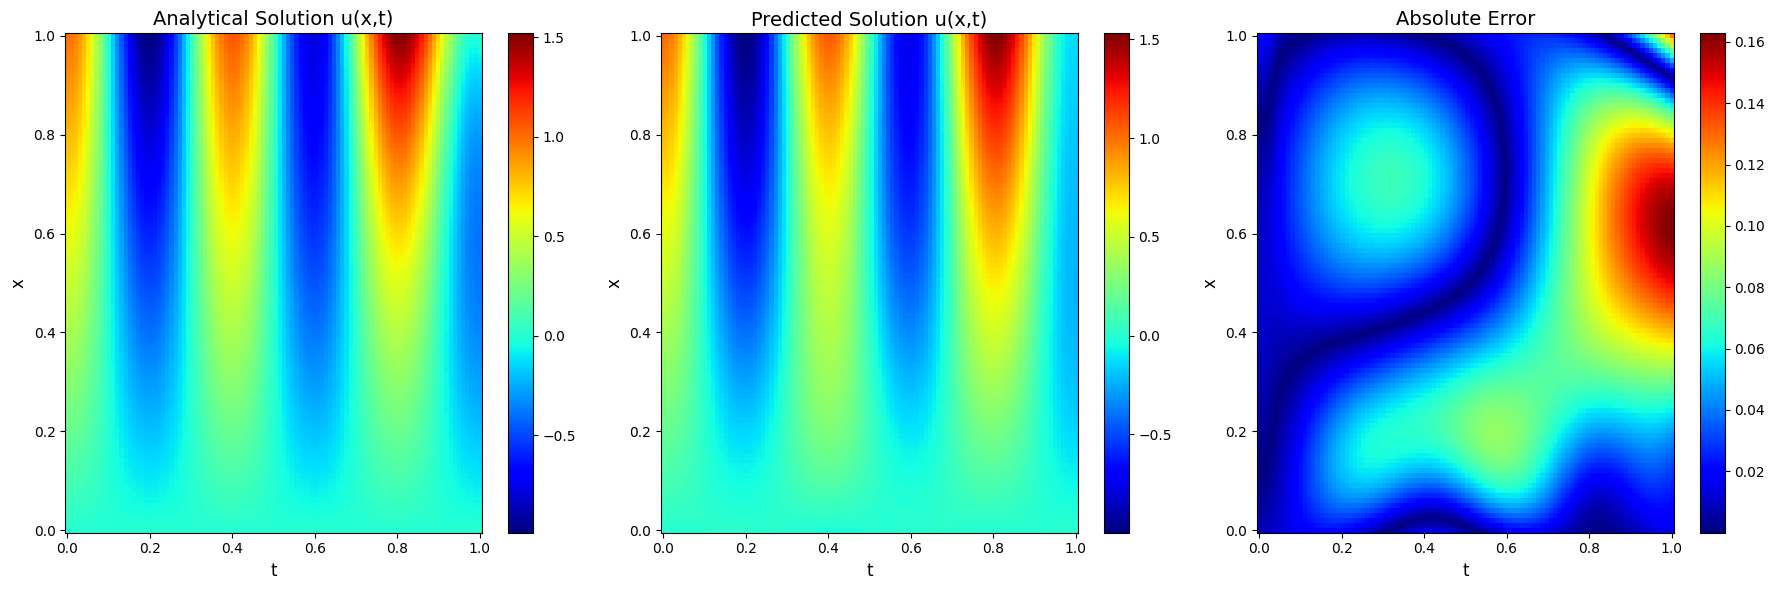

总体u的L2误差: 0.058128


In [124]:
# 创建网格点
nx, nt = 100, 100
x = torch.linspace(0, 1, nx).reshape(-1, 1)  # 范围保持[0,1]
t = torch.linspace(0, 1, nt).reshape(-1, 1)  # 范围改为[0,1]

X, T = torch.meshgrid(x.squeeze(), t.squeeze(), indexing='ij')

X_flat = X.reshape(-1, 1)
T_flat = T.reshape(-1, 1)

# 组合输入
X_test = torch.cat([T_flat, X_flat], dim=1)

# 模型预测
with torch.no_grad():
    u_pred = model(X_test).reshape(nx, nt).detach().numpy()

# 解析解
u_exact = analytical_solution(T_flat, X_flat).reshape(nx, nt).detach().numpy()

# 计算误差
u_error = np.abs(u_pred - u_exact)

# 显示热图对比
plt.figure(figsize=(18, 6))

plt.subplot(131)
im = plt.pcolormesh(T.numpy(), X.numpy(), u_exact, cmap='jet', shading='auto')
plt.colorbar(im)
plt.xlabel('t', fontsize=12)
plt.ylabel('x', fontsize=12)
plt.title('Analytical Solution u(x,t)', fontsize=14)

plt.subplot(132)
im = plt.pcolormesh(T.numpy(), X.numpy(), u_pred, cmap='jet', shading='auto')
plt.colorbar(im)
plt.xlabel('t', fontsize=12)
plt.ylabel('x', fontsize=12)
plt.title('Predicted Solution u(x,t)', fontsize=14)

plt.subplot(133)
im = plt.pcolormesh(T.numpy(), X.numpy(), u_error, cmap='jet', shading='auto')
plt.colorbar(im)
plt.xlabel('t', fontsize=12)
plt.ylabel('x', fontsize=12)
plt.title('Absolute Error', fontsize=14)

plt.tight_layout()
plt.show()

# 计算L2误差
total_u_l2_error = np.sqrt(np.mean(np.square(u_pred - u_exact)))
print(f"总体u的L2误差: {total_u_l2_error:.6f}")

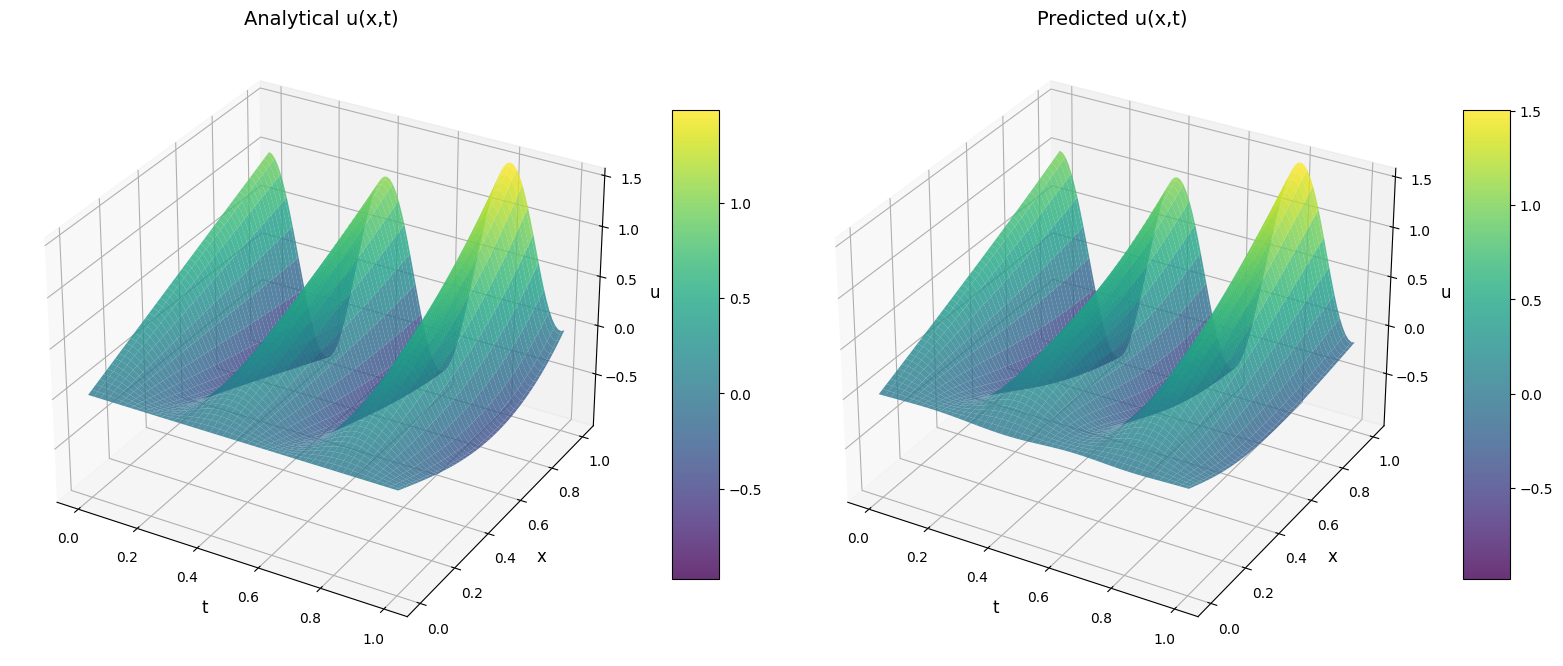

In [125]:
# 3D表面图对比 - 展示u解的三维视图
fig = plt.figure(figsize=(16, 7))

# 解析解的3D表面图
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(T.numpy(), X.numpy(), u_exact, cmap='viridis', 
                       linewidth=0, antialiased=True, alpha=0.8)
fig.colorbar(surf1, ax=ax1, shrink=0.7, aspect=10)
ax1.set_xlabel('t', fontsize=12)
ax1.set_ylabel('x', fontsize=12)
ax1.set_zlabel('u', fontsize=12)
ax1.set_title('Analytical u(x,t)', fontsize=14)

# 预测值的3D表面图
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(T.numpy(), X.numpy(), u_pred, cmap='viridis', 
                       linewidth=0, antialiased=True, alpha=0.8)
fig.colorbar(surf2, ax=ax2, shrink=0.7, aspect=10)
ax2.set_xlabel('t', fontsize=12)
ax2.set_ylabel('x', fontsize=12)
ax2.set_zlabel('u', fontsize=12)
ax2.set_title('Predicted u(x,t)', fontsize=14)

plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


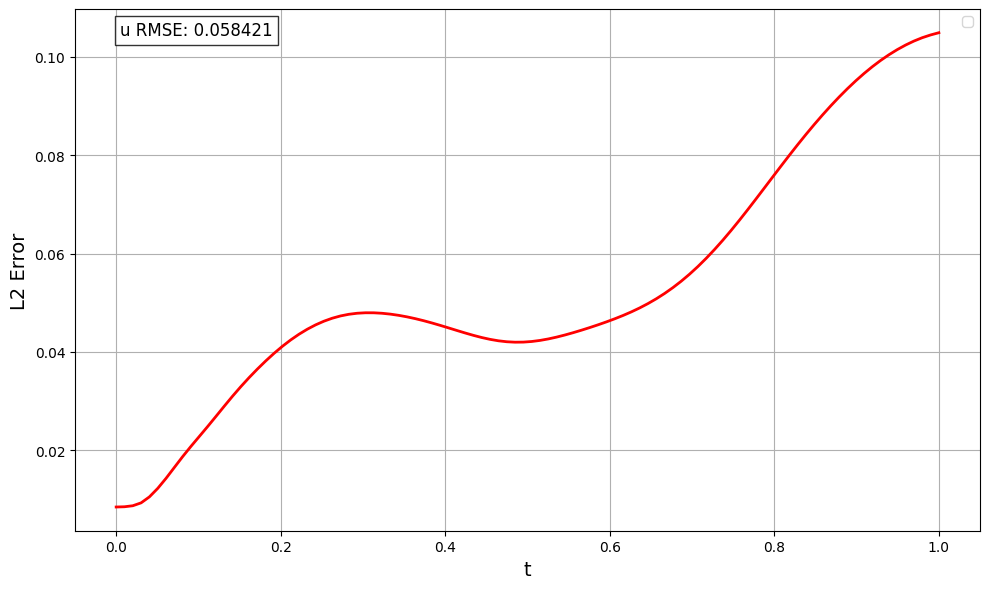

In [126]:
def compute_and_plot_l2_error(u_analytical, u_predicted, t_points, x_range):
    """计算并绘制不同时间点上的L2误差"""
    # 计算空间步长(用于数值积分)
    dx = (x_range[1] - x_range[0]) / (u_analytical.shape[0] - 1)
    
    # 初始化L2误差数组
    l2_errors_u = np.zeros(len(t_points))
    
    # 对每个时间点计算L2误差
    for i in range(len(t_points)):
        # 计算u的L2误差
        squared_error_u = (u_analytical[:, i] - u_predicted[:, i])**2
        l2_errors_u[i] = np.sqrt(np.sum(squared_error_u) * dx)
    
    # 绘制L2误差随时间的变化
    plt.figure(figsize=(10, 6))
    plt.plot(t_points, l2_errors_u, 'r-', linewidth=2)
    plt.grid(True)
    plt.xlabel('t', fontsize=14)
    plt.ylabel('L2 Error', fontsize=14)
    plt.legend()
    
    # 添加均方根误差信息
    rmse_u = np.sqrt(np.mean(l2_errors_u**2))
    plt.text(0.05, 0.95, f'u RMSE: {rmse_u:.6f}', 
             transform=plt.gca().transAxes, fontsize=12, 
             bbox=dict(facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    return l2_errors_u

# 使用该函数计算并绘制L2误差
t_points = t.squeeze().numpy()  # 时间点数组
x_range = [0, 1]  # x的范围

# 计算并绘制L2误差
l2_errors_u = compute_and_plot_l2_error(
    u_analytical=u_exact, 
    u_predicted=u_pred,
    t_points=t_points,
    x_range=x_range
)
